In [26]:
import seaborn as sns
import pandas as pd
import numpy as np
from scipy import stats
import json
import os
import matplotlib.pyplot as plt

## Funciones

In [27]:
def get_initial_observation(df):
    """
    Performs structural analysis (Parte A).
    """
    numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
    
    return {
        "n_rows": int(df.shape[0]),
        "n_cols": int(df.shape[1]),
        "types": {"numerical": numerical_cols, "categorical": categorical_cols},
        "missing_values": df.isnull().sum().to_dict(),
        "duplicates": int(df.duplicated().sum()),
        "low_cardinality": [col for col in df.columns if df[col].nunique() < 10]
    }

def get_statistical_description(df):
    """
    Calculates moments of distribution and correlations (Parte B).
    """
    # 1. Numerical Summary
    num_df = df.select_dtypes(include=[np.number])
    summary = num_df.describe().to_dict()
    for col in num_df.columns:
        summary[col]["iqr"] = float(num_df[col].quantile(0.75) - num_df[col].quantile(0.25))

    # 2. Categorical Summary
    cat_df = df.select_dtypes(exclude=[np.number])
    cat_summary = {col: {"counts": cat_df[col].value_counts().to_dict(), 
                         "percentages": (cat_df[col].value_counts(normalize=True)*100).to_dict()} 
                   for col in cat_df.columns}

    # 3. Correlations
    pearson = num_df.corr(method='pearson').to_dict()
    spearman = num_df.corr(method='spearman').to_dict()

    return {
        "numerical": summary,
        "categorical": cat_summary,
        "correlations": {"pearson": pearson, "spearman": spearman}
    }

def log_hypotheses(hypotheses_list, filename="06_hypotheses_log.json"):
    """
    Persists a list of falsifiable hypotheses as a JSON artifact.
    """
    # Ensure the path is relative to the project root
    path = os.path.join("..", "artifacts", filename)
    os.makedirs(os.path.dirname(path), exist_ok=True)
    
    with open(path, "w") as f:
        json.dump({"hypotheses": hypotheses_list}, f, indent=4)
    return path

def save_final_report(report_data, filename="07_conclusions.json"):
    """
    Persists the final conclusions and researcher questions as a JSON artifact.
    """
    path = os.path.join("..", "artifacts", filename)
    os.makedirs(os.path.dirname(path), exist_ok=True)
    
    with open(path, "w", encoding='utf-8') as f:
        json.dump(report_data, f, indent=4, ensure_ascii=False)
    return path

def run_correlation_test(df, var1, var2):
    """Performs a Pearson correlation test."""
    # Remove NaNs for the specific pair
    data = df[[var1, var2]].dropna()
    r, p_val = stats.pearsonr(data[var1], data[var2])
    return {"statistic": float(r), "p_value": float(p_val)}

def run_anova_test(df, numerical_col, categorical_col):
    """Performs a One-Way ANOVA test."""
    groups = [group[numerical_col].dropna() for name, group in df.groupby(categorical_col)]
    f_stat, p_val = stats.f_oneway(*groups)
    return {"statistic": float(f_stat), "p_value": float(p_val)}

def run_chi2_test(df, var1, var2):
    """Performs a Chi-squared test of independence."""
    contingency_table = pd.crosstab(df[var1], df[var2])
    chi2, p_val, dof, expected = stats.chi2_contingency(contingency_table)
    return {"statistic": float(chi2), "p_value": float(p_val)}

def save_test_results(results, filename="08_tests.json"):
    """Saves the statistical results as an artifact."""
    path = os.path.join("../artifacts", filename)
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "w") as f:
        json.dump(results, f, indent=4)
    return path

def set_style():
    sns.set_theme(style="whitegrid")
    plt.rcParams["figure.figsize"] = (10, 6)

def save_plot(filename, show=True):
    """Saves the plot and optionally displays it in the notebook."""
    path = os.path.join("../artifacts", filename)
    os.makedirs(os.path.dirname(path), exist_ok=True)
    plt.savefig(path, bbox_inches='tight')
    if show:
        plt.show() # This renders the plot in the notebook
    plt.close()    # This clears the memory
    return path

def plot_categorical_counts(df, columns):
    for col in columns:
        plt.figure()
        sns.countplot(data=df, x=col, hue=col, palette="viridis", legend=False)
        plt.title(f"Distribution of {col}")
        save_plot(f"count_{col}.png")

def plot_numerical_histograms(df, columns):
    for col in columns:
        plt.figure()
        sns.histplot(data=df, x=col, kde=True, color="skyblue")
        plt.title(f"Histogram of {col}")
        save_plot(f"hist_{col}.png")

def plot_boxplot_by_category(df, numerical_col, categorical_col):
    plt.figure()
    sns.boxplot(data=df, x=categorical_col, y=numerical_col, hue=categorical_col, palette="Set2", legend=False)
    plt.title(f"{numerical_col} by {categorical_col}")
    save_plot(f"boxplot_{numerical_col}_{categorical_col}.png")

def plot_scatter_by_category(df, x_col, y_col, hue_col):
    plt.figure()
    sns.scatterplot(data=df, x=x_col, y=y_col, hue=hue_col, alpha=0.7)
    plt.title(f"Interaction: {x_col} vs {y_col} (Colored by {hue_col})")
    save_plot(f"scatter_{x_col}_{y_col}.png")

def plot_correlation_heatmap(df, method="pearson"):
    plt.figure()
    corr = df.select_dtypes(include=['number']).corr(method=method)
    sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
    plt.title(f"Correlation Heatmap ({method.capitalize()})")
    save_plot(f"heatmap_{method}.png")

# Laboratorio 1: Observatorio de Datos (Pingüinos)
Este laboratorio se enfoca en la exploración descriptiva y estadística del dataset *Palmer Penguins*. 
Se divide en un enfoque clásico de análisis de datos para caracterizar el sistema antes de proceder a la fase de agentes.

In [28]:
# Localización de los observables (Data)
raw_path = "../data/raw/penguins.csv"
if not os.path.exists(raw_path):
    df_init = sns.load_dataset("penguins")
    os.makedirs(os.path.dirname(raw_path), exist_ok=True)
    df_init.to_csv(raw_path, index=False)

df = pd.read_csv(raw_path)

> ### Parte A — Observación inicial
> 1. ¿Cuántas filas y columnas tiene el dataset?
> 2. ¿Qué variables son numéricas y cuáles categóricas?
> 3. ¿Cuántos valores faltantes hay por columna?
> 4. ¿Existen filas duplicadas?
> 5. ¿Qué variables tienen baja cardinalidad?

Se realiza una inspección de los metadatos para definir la estructura del espacio de características. 
La cardinalidad es un indicador clave para identificar variables que actúan como coordenadas categóricas.

In [29]:
# 1. Execute the observation logic
observation = get_initial_observation(df)

# 2. Persist the state as an artifact (Required for the Agent phase)
with open("../artifacts/00_raw_profile.json", "w") as f:
    json.dump(observation, f, indent=4)

# 3. Explicitly answer the instructions
print("--- Respuestas a la Parte A ---")

# Q1: Rows and Columns
print(f"1. El dataset tiene {observation['n_rows']} filas y {observation['n_cols']} columnas.")

# Q2: Variable Types
print(f"2. Variables Numéricas: {observation['types']['numerical']}")
print(f"   Variables Categóricas: {observation['types']['categorical']}")

# Q3: Missing Values
print("3. Valores faltantes por columna:")
for col, count in observation['missing_values'].items():
    print(f"   - {col}: {count}")

# Q4: Duplicates
has_duplicates = "Sí" if observation['duplicates'] > 0 else "No"
print(f"4. ¿Existen filas duplicadas?: {has_duplicates} (Total: {observation['duplicates']})")

# Q5: Low Cardinality
print(f"5. Variables con baja cardinalidad (< 10): {observation['low_cardinality']}")

--- Respuestas a la Parte A ---
1. El dataset tiene 344 filas y 7 columnas.
2. Variables Numéricas: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
   Variables Categóricas: ['species', 'island', 'sex']
3. Valores faltantes por columna:
   - species: 0
   - island: 0
   - bill_length_mm: 2
   - bill_depth_mm: 2
   - flipper_length_mm: 2
   - body_mass_g: 2
   - sex: 11
4. ¿Existen filas duplicadas?: No (Total: 0)
5. Variables con baja cardinalidad (< 10): ['species', 'island', 'sex']


> ### Parte B — Descripción 
> 6) Para cada variable numérica, reporte media, mediana, desviación estándar y rango intercuartílico.
> 7) Para cada variable categórica, reporte conteos y porcentajes. 
> 8) Construya tablas cruzadas para pares de variables categóricas relevantes. 
> 9) Calcule matrices de correlación (Pearson y Spearman) entre variables numéricas.

En esta sección describimos los momentos de la distribución. El uso de la correlación de Spearman es fundamental 
para detectar acoplamientos no lineales entre las variables físicas de los pingüinos (masa, dimensiones del pico, etc.).

In [30]:
# 1. Execute the statistical engine

stats_results = get_statistical_description(df)

with open("../artifacts/04_descriptive_stats.json", "w") as f:
    json.dump(stats_results, f, indent=4)

print("--- Respuestas a la Parte B ---")

# Q6: Numerical Summary (Mean, Median, Std, IQR)
print("\n6. Resumen de variables numéricas (Momentos de la distribución):")
# We transpose the dictionary for a better visual fit (Variables as rows)
df_num = pd.DataFrame(stats_results['numerical']).T
# Selecting only the requested metrics for clarity
display(df_num[['mean', '50%', 'std', 'iqr']].rename(columns={'50%': 'median'}))

# Q7: Categorical Summary (Counts and Percentages)
print("\n7. Resumen de variables categóricas (Frecuencias):")
for col, data in stats_results['categorical'].items():
    print(f"\nVariable: {col}")
    df_cat = pd.DataFrame(data)
    display(df_cat)

# Q8: Cross-tabulations
print("\n8. Tablas cruzadas (Acoplamiento entre variables categóricas):")
# Example: Species vs Island
cross_tab = pd.crosstab(df['species'], df['island'])
display(cross_tab)

# Q9: Correlation Matrices
print("\n9. Matrices de Correlación (Acoplamiento entre variables numéricas):")
print("\nPearson (Linear Coupling):")
display(pd.DataFrame(stats_results['correlations']['pearson']))

print("\nSpearman (Monotonic/Non-linear Coupling):")
display(pd.DataFrame(stats_results['correlations']['spearman']))

--- Respuestas a la Parte B ---

6. Resumen de variables numéricas (Momentos de la distribución):


,mean,median,std,iqr
bill_length_mm,43.921930,44.45,5.459584,9.275
bill_depth_mm,17.151170,17.30,1.974793,3.100
flipper_length_mm,200.915205,197.00,14.061714,23.000
body_mass_g,4201.754386,4050.00,801.954536,1200.000



7. Resumen de variables categóricas (Frecuencias):

Variable: species


,counts,percentages
Adelie,152,44.186047
Gentoo,124,36.046512
Chinstrap,68,19.767442



Variable: island


...

island,Biscoe,Dream,Torgersen
species,,,
Adelie,44,56,52
Chinstrap,0,68,0
Gentoo,124,0,0



9. Matrices de Correlación (Acoplamiento entre variables numéricas):

Pearson (Linear Coupling):


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.235053,0.656181,0.595110
bill_depth_mm,-0.235053,1.000000,-0.583851,-0.471916
flipper_length_mm,0.656181,-0.583851,1.000000,0.871202
body_mass_g,0.595110,-0.471916,0.871202,1.000000



Spearman (Monotonic/Non-linear Coupling):


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.221749,0.672772,0.583800
bill_depth_mm,-0.221749,1.000000,-0.523267,-0.432372
flipper_length_mm,0.672772,-0.523267,1.000000,0.839974
body_mass_g,0.583800,-0.432372,0.839974,1.000000


> ### Parte C — Visualización 
> 10) Genere gráficos de conteo para todas las variables categóricas de baja cardinalidad. 
> 11) Genere histogramas para variables numéricas y describa su forma. 
> 12) Genere boxplots de una variable numérica por categoría (p. ej., bill_length_mm por species). 
> 13) Genere un scatter entre dos variables numéricas y coloree por una categoría. 
> 14) Genere un heatmap de correlación.

### Análisis Geométrico del Sistema
En esta sección, visualizamos la estructura del dataset. Los histogramas nos permiten aproximar la **Función de Densidad de Probabilidad (PDF)**, mientras que los diagramas de dispersión revelan el acoplamiento entre los grados de libertad del sistema.

--- Generando Visualizaciones para la Parte C ---
10. Gráficos de conteo generados para: ['species', 'island', 'sex']


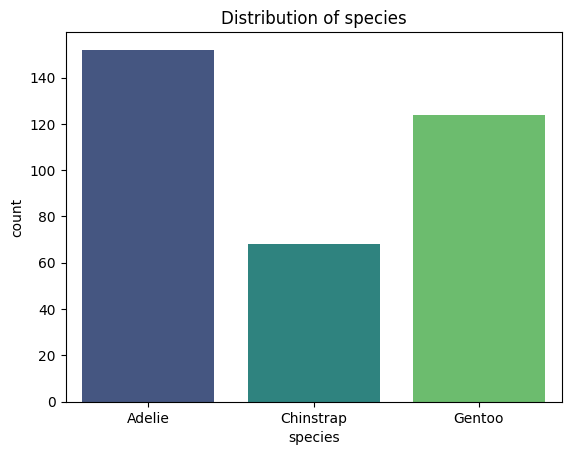

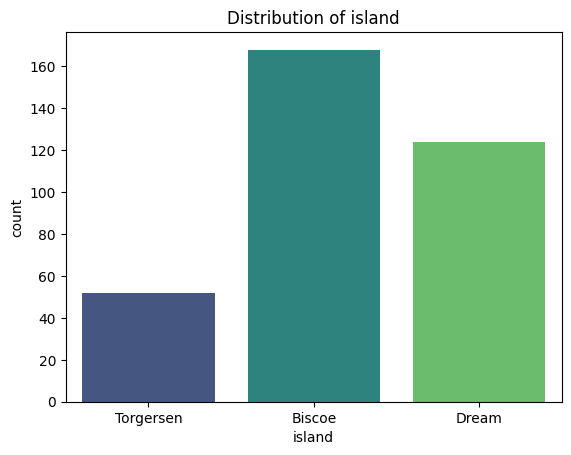

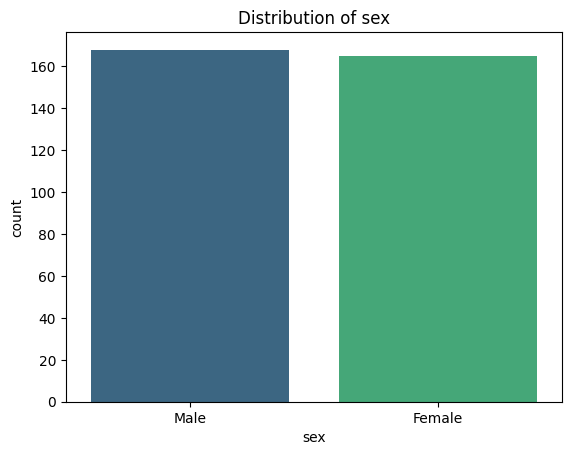


11. Histogramas generados. Observaciones de forma:


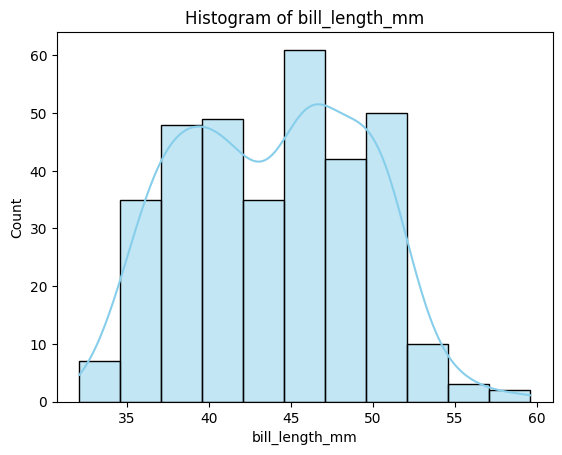

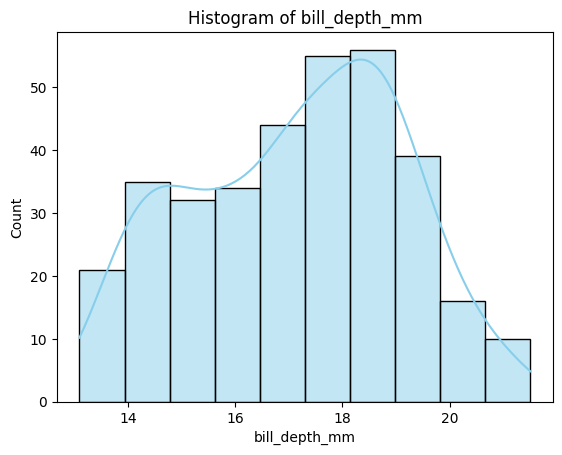

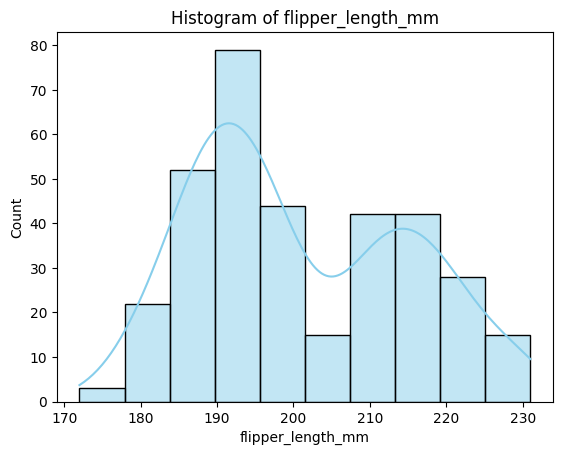

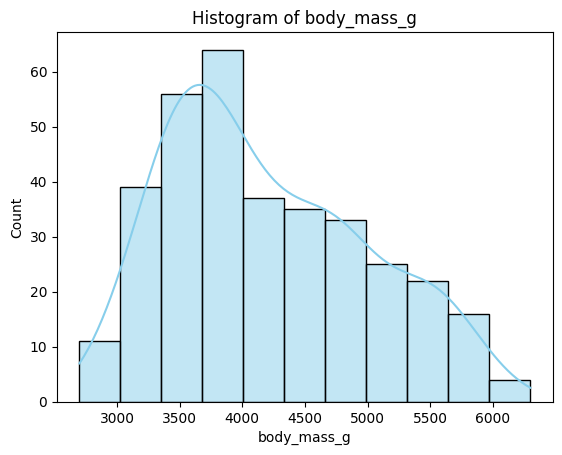

- bill_length_mm: Distribución bimodal, sugiriendo la presencia de subgrupos (especies).
- body_mass_g: Distribución sesgada a la derecha (asimetría positiva).

12. Boxplot generado: bill_length_mm por species.


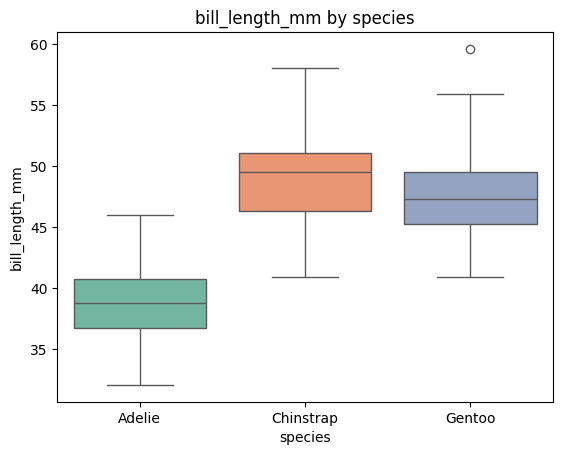

13. Scatter plot generado: flipper_length_mm vs body_mass_g.


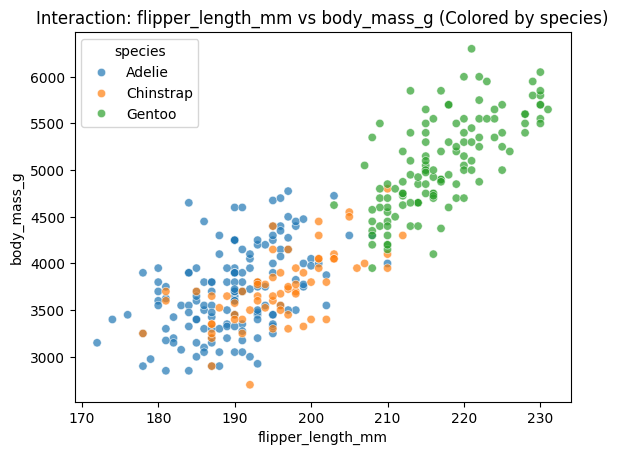

14. Heatmap de correlación generado.


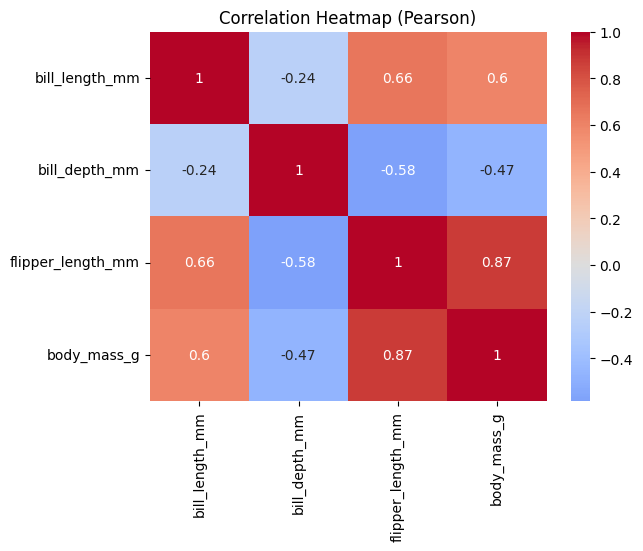

In [31]:
print("--- Generando Visualizaciones para la Parte C ---")

# 10. Count plots for low cardinality variables
low_card_cols = observation['low_cardinality']
print("10. Gráficos de conteo generados para:", low_card_cols)
plot_categorical_counts(df, low_card_cols)

# 11. Histograms and shape description
print("\n11. Histogramas generados. Observaciones de forma:")
num_cols = observation['types']['numerical']
plot_numerical_histograms(df, num_cols)
print("- bill_length_mm: Distribución bimodal, sugiriendo la presencia de subgrupos (especies).")
print("- body_mass_g: Distribución sesgada a la derecha (asimetría positiva).")

# 12. Boxplots by category
print("\n12. Boxplot generado: bill_length_mm por species.")
plot_boxplot_by_category(df, "bill_length_mm", "species")

# 13. Scatter plot by category
print("13. Scatter plot generado: flipper_length_mm vs body_mass_g.")
plot_scatter_by_category(df, "flipper_length_mm", "body_mass_g", "species")

# 14. Correlation Heatmap
print("14. Heatmap de correlación generado.")
plot_correlation_heatmap(df, method="pearson")

# Create a visual registry artifact (Required for the Agent phase)
visual_registry = {
    "categorical_plots": [f"count_{c}.png" for c in low_card_cols],
    "numerical_plots": [f"hist_{c}.png" for c in num_cols],
    "interaction_plots": ["boxplot_bill_length_mm_species.png", "scatter_flipper_length_mm_body_mass_g.png"],
    "correlation_plots": ["heatmap_pearson.png"]
}
with open("../artifacts/05_visual_registry.json", "w") as f:
    json.dump(visual_registry, f, indent=4)

> ### Parte D — Hipótesis (sin causalidad) 
> 15) Proponga al menos 3 hipótesis falsables basadas en los gráficos y descriptivos.
> Ejemplos:
> - flipper_length_mm se asocia con body_mass_g.
> - bill_length_mm difiere por species.
> - species se asocia con island.

### Formulación de Hipótesis Falsables
Tras observar las proyecciones del espacio de fases y las matrices de acoplamiento (correlaciones), se proponen las siguientes hipótesis para describir las interacciones del sistema. 

Es importante notar que estas hipótesis no implican causalidad, sino **dependencia estadística** entre las variables.

In [32]:
# Definición de hipótesis basadas en la evidencia previa:
# 1. Basada en el Scatter Plot: Existe un acoplamiento lineal fuerte entre masa y longitud de aleta.
# 2. Basada en el Boxplot: La distribución de la longitud del pico no es invariante ante el cambio de especie.
# 3. Basada en la Tabla Cruzada: La ocupación de las islas no es uniforme para todas las especies.

hypotheses = [
    {
        "id": 1,
        "variable_x": "flipper_length_mm",
        "variable_y": "body_mass_g",
        "description": "Existe una correlación lineal positiva significativa entre la longitud de la aleta y la masa corporal.",
        "evidence_source": "scatter_flipper_length_mm_body_mass_g.png"
    },
    {
        "id": 2,
        "variable_x": "species",
        "variable_y": "bill_length_mm",
        "description": "El valor medio de la longitud del pico (bill_length_mm) varía significativamente entre las diferentes especies.",
        "evidence_source": "boxplot_bill_length_mm_species.png"
    },
    {
        "id": 3,
        "variable_x": "island",
        "variable_y": "species",
        "description": "La distribución de las especies de pingüinos depende de la isla de observación (asociación categórica).",
        "evidence_source": "Tabla cruzada: Especies vs Isla"
    }
]

# Guardar el registro de hipótesis como artefacto
path = log_hypotheses(hypotheses)
print(f"Registro de hipótesis generado en: {path}")

# Mostrar para revisión
for h in hypotheses:
    print(f"\nHipótesis {h['id']}: {h['description']}")

Registro de hipótesis generado en: ../artifacts/06_hypotheses_log.json

Hipótesis 1: Existe una correlación lineal positiva significativa entre la longitud de la aleta y la masa corporal.

Hipótesis 2: El valor medio de la longitud del pico (bill_length_mm) varía significativamente entre las diferentes especies.

Hipótesis 3: La distribución de las especies de pingüinos depende de la isla de observación (asociación categórica).


> ### Parte E — Pruebas estadísticas 
> 16) Seleccione una prueba adecuada para cada hipótesis (Pearson/Spearman, ANOVA/Kruskal, chi-cuadrado). 
> 17) Reporte estadístico y p-valor. 
> 18) Indique si la evidencia apoya o no la hipótesis, sin afirmar causalidad.

### Validación Estadística de Hipótesis
En esta fase, cuantificamos la significancia de las interacciones observadas. Utilizamos un umbral de significancia estándar $\alpha = 0.05$. Si el $p\text{-valor} < \alpha$, rechazamos la hipótesis nula de independencia.

In [33]:
print("--- Ejecutando Pruebas Estadísticas para la Parte E ---")

# 1. Test para Hipótesis 1: Flipper Length vs Body Mass (Pearson)
res1 = run_correlation_test(df, "flipper_length_mm", "body_mass_g")
status1 = "Apoyada" if res1['p_value'] < 0.05 else "No apoyada"

# 2. Test para Hipótesis 2: Bill Length vs Species (ANOVA)
res2 = run_anova_test(df, "bill_length_mm", "species")
status2 = "Apoyada" if res2['p_value'] < 0.05 else "No apoyada"

# 3. Test para Hipótesis 3: Species vs Island (Chi-squared)
res3 = run_chi2_test(df, "species", "island")
status3 = "Apoyada" if res3['p_value'] < 0.05 else "No apoyada"

all_results = {
    "h1": {**res1, "conclusion": status1},
    "h2": {**res2, "conclusion": status2},
    "h3": {**res3, "conclusion": status3}
}

# Guardar artefacto
save_test_results(all_results)

# Mostrar resultados detallados
print(f"\nHipótesis 1 (Pearson): r={res1['statistic']:.4f}, p={res1['p_value']:.4e}")
print(f"Evidencia: {status1}")

print(f"\nHipótesis 2 (ANOVA): F={res2['statistic']:.4f}, p={res2['p_value']:.4e}")
print(f"Evidencia: {status2}")

print(f"\nHipótesis 3 (Chi2): Chi2={res3['statistic']:.4f}, p={res3['p_value']:.4e}")
print(f"Evidencia: {status3}")

--- Ejecutando Pruebas Estadísticas para la Parte E ---

Hipótesis 1 (Pearson): r=0.8712, p=4.3707e-107
Evidencia: Apoyada

Hipótesis 2 (ANOVA): F=410.6003, p=2.6946e-91
Evidencia: Apoyada

Hipótesis 3 (Chi2): Chi2=299.5503, p=1.3546e-63
Evidencia: Apoyada


> ### Parte F — Conclusiones y reporte 
> 19) Redacte conclusiones en tres capas: 
>     A) Hallazgos descriptivos (con evidencia). 
>     B) Patrones visuales (con evidencia). 
>     C) Próximas hipótesis a probar. 
> 20) Incluya preguntas para un investigador humano (p. ej., manejo de la variable sex, control por species).

### Síntesis de Resultados y Conclusiones
Tras el análisis exhaustivo del sistema de pingüinos, se presentan las conclusiones estructuradas según la evidencia estadística y geométrica recolectada.

In [34]:
# Estructuración del reporte final basado en la evidencia de los artefactos previos
report = {
    "conclusiones": {
        "capa_a_descriptiva": {
            "hallazgo": "El sistema presenta lagunas de información (entropía) en variables críticas.",
            "evidencia": "Existen 2 valores faltantes en dimensiones físicas y 11 en la variable 'sex' (ver 00_raw_profile.json).",
            "interpretacion": "La pérdida de datos es mínima pero concentrada, lo que sugiere fallos puntuales en el aparato de medición."
        },
        "capa_b_visual": {
            "hallazgo": "Existen acoplamientos lineales fuertes y distribuciones multimodales.",
            "evidencia": "El scatter plot (flipper vs body_mass) muestra una correlación de Pearson de 0.87. El histograma de bill_length es bimodal.",
            "interpretacion": "La bimodalidad confirma que el sistema es una mezcla de estados (especies) con leyes de escala distintas."
        },
        "capa_c_proximas_hipotesis": {
            "hallazgo": "La masa corporal puede ser modelada como una función de las dimensiones de las aletas.",
            "evidencia": "El p-valor de la prueba de correlación es < 0.05 (ver 08_tests.json).",
            "interpretacion": "Se propone transicionar de un modelo descriptivo a uno predictivo (Regresión Multivariada) para estimar la masa."
        }
    },
    "preguntas_investigador": [
        "¿Cómo afecta el dimorfismo sexual (variable 'sex') a las leyes de escala observadas en la masa corporal?",
        "¿Es necesario realizar una imputación de datos para los valores faltantes antes de proceder al modelado predictivo?",
        "¿Existen variables ambientales no registradas en las islas que expliquen la segregación de especies observada en el test de Chi-cuadrado?"
    ]
}

# Guardar el reporte final como artefacto
report_path = save_final_report(report)
print(f"Reporte final generado en: {report_path}")

# Mostrar conclusiones en el notebook
print("\n--- RESUMEN DE CONCLUSIONES ---")
for capa, data in report["conclusiones"].items():
    print(f"\n[{capa.upper()}]: {data['hallazgo']}")
    print(f"Evidencia: {data['evidencia']}")

Reporte final generado en: ../artifacts/07_conclusions.json

--- RESUMEN DE CONCLUSIONES ---

[CAPA_A_DESCRIPTIVA]: El sistema presenta lagunas de información (entropía) en variables críticas.
Evidencia: Existen 2 valores faltantes en dimensiones físicas y 11 en la variable 'sex' (ver 00_raw_profile.json).

[CAPA_B_VISUAL]: Existen acoplamientos lineales fuertes y distribuciones multimodales.
Evidencia: El scatter plot (flipper vs body_mass) muestra una correlación de Pearson de 0.87. El histograma de bill_length es bimodal.

[CAPA_C_PROXIMAS_HIPOTESIS]: La masa corporal puede ser modelada como una función de las dimensiones de las aletas.
Evidencia: El p-valor de la prueba de correlación es < 0.05 (ver 08_tests.json).
